In [98]:
import pandas as pd
import numpy as np
import warnings
from datetime import datetime
import re
import lightgbm as lgb
import xgboost as xgb
import shap
# import optuna
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
# optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV

In [99]:
def mohra_raneem_features(df):
    df = df.copy()
    le = LabelEncoder()
    binary_text_columns = ['SupportURL', 'SupportEmail', 'Website', 'ExtUserAcctNotice',
                           'DRMNotice', 'Background', 'HeaderImage','LegalNotice','IsFree','FreeVerAvail','PlatformMac','PlatformLinux','PlatformWindows',
                           'GenreIsMassivelyMultiplayer','GenreIsRacing','GenreIsSports','GenreIsFreeToPlay','GenreIsEarlyAccess','GenreIsSimulation',
                           'GenreIsRPG','GenreIsStrategy','GenreIsCasual','GenreIsAdventure','GenreIsAction','GenreIsIndie','GenreIsNonGame''CategoryMultiplayer', 'CategoryCoop', 'CategoryMMO']
    for col in binary_text_columns:
        if col in df.columns:
            df[col] = df[col].fillna('').astype(str).str.strip().ne('').astype(int)


    df["GamePopularity"]=le.fit_transform(df["GamePopularity"])

    # Reviews → extract sentiment signals instead of just binary
    if 'Reviews' in df.columns:
        positive_words = ['great', 'amazing', 'fun', 'recommend', 'excellent', 'love', 'best', 'fantastic', 'perfect', 'good']
        negative_words = ['bad', 'terrible', 'boring', 'waste', 'buggy', 'broken', 'awful', 'worst', 'crash', 'disappointment']
        df['Review_Has_Content'] = df['Reviews'].fillna('').astype(str).str.strip().ne('').astype(int)
        df['Review_Positive_Signals'] = df['Reviews'].apply(
            lambda x: sum(w in str(x).lower() for w in positive_words) if isinstance(x, str) else 0
        )
        df['Review_Negative_Signals'] = df['Reviews'].apply(
            lambda x: sum(w in str(x).lower() for w in negative_words) if isinstance(x, str) else 0
        )
        df['Review_Sentiment_Score'] = df['Review_Positive_Signals'] - df['Review_Negative_Signals']
        df.drop(columns=['Reviews'], inplace=True)



    # Text length features
    textto_num_cols = ['DetailedDescrip', 'AboutText', 'ShortDescrip']
    for col in textto_num_cols:
        if col in df.columns:
            df[col] = df[col].fillna('').astype(str).str.len()



    common_langs = ['English', 'French', 'German', 'Italian', 'Spanish', 'Korean', 'Japanese', 'Russian', 'Turkish',
                    'Thai', 'Portuguese', 'Polish', 'Dutch', 'Arabic', 'Simplified Chinese', 'Traditional Chinese',
                    'Czech', 'Hungarian', 'Romanian']

    if 'SupportedLanguages' in df.columns:
        df['NumLanguages'] = df['SupportedLanguages'].apply(
            lambda x: sum(1 for l in common_langs if isinstance(x, str) and l in x)
        )
        # has major Asian language support
        asian_langs = ['Korean', 'Japanese', 'Simplified Chinese', 'Traditional Chinese']
        df['Has_Asian_Languages'] = df['SupportedLanguages'].apply(
            lambda x: int(any(l in str(x) for l in asian_langs))
        )

    bool_cols = df.select_dtypes(include='bool').columns.tolist()
    if bool_cols:
        df[bool_cols] = df[bool_cols].astype(int)

    if 'ReleaseDate' in df.columns:
        df['ReleaseDate'] = pd.to_datetime(df['ReleaseDate'], errors='coerce')
        median_date = df['ReleaseDate'].dropna().median()
        df['ReleaseDate'] = df['ReleaseDate'].fillna(median_date)
        df['ReleaseDate_Year'] = df['ReleaseDate'].dt.year.astype('Int64')
        df['ReleaseDate_Month'] = df['ReleaseDate'].dt.month.astype('Int64')
        df['ReleaseDate_Day'] = df['ReleaseDate'].dt.day.astype('Int64')
        df['GameAge'] = datetime.now().year - df['ReleaseDate_Year']
        #  holiday release window (Nov-Dec = high sales season)
        df['Is_Holiday_Release'] = df['ReleaseDate_Month'].apply(
            lambda x: 1 if x in [11, 12] else 0
        )
        #  Quarter of release
        df['Release_Quarter'] = np.ceil(df['ReleaseDate_Month'] / 3).astype('Int64')

    if 'PriceCurrency' in df.columns:
        df['PriceCurrency'] = df['PriceCurrency'].astype(str).str.strip().replace('', 'USD')
        df['PriceCurrency'] = (df['PriceCurrency'] == 'USD').astype(int)


    def extract_reqs(text):
        if not isinstance(text, str) or not text.strip():
            return {'RAM_GB': None, 'Storage_GB': None, 'CPU_GHz': None, 'OpenGL': None}

        ram = re.findall(r'(\d+)\s*(GB|mb)\s*(?:Memory|RAM)', text, re.IGNORECASE)
        storage = re.findall(r'(\d+)\s*GB\s*Hard\s*Drive', text, re.IGNORECASE)
        ghz = re.findall(r'(\d+\.?\d*)\s*(GHz|mhz)', text, re.IGNORECASE)
        opengl = re.findall(r'OpenGL\s*(\d+\.?\d*)', text, re.IGNORECASE)
        cpu = None
        if ghz:
            value, unit = ghz[0]
            value = float(value)
            if unit.lower() == 'mhz':
                value = value / 1000
            cpu = value

        Ram = None
        if ram:
            value, unit = ram[0]
            value = float(value)
            if unit.lower() == 'mb':
                value = value / 1000
            Ram = value

        return {
            'RAM_GB': Ram,
            'Storage_GB': int(storage[0]) if storage else None,
            'CPU_GHz': cpu,
            'OpenGL': float(opengl[0]) if opengl else None
        }

    if 'LinuxMinReqsText' in df.columns:
        linux = df['LinuxMinReqsText'].apply(extract_reqs).apply(pd.Series)
        linux.columns = ['Linux_RAM_GB', 'Linux_Storage_GB', 'Linux_CPU_GHz', 'Linux_OpenGL']
        df = pd.concat([df, linux], axis=1)

    if 'MacMinReqsText' in df.columns:
        mac = df['MacMinReqsText'].apply(extract_reqs).apply(pd.Series)
        mac.columns = ['Mac_RAM_GB', 'Mac_Storage_GB', 'Mac_CPU_GHz', 'Mac_OpenGL']
        df = pd.concat([df, mac], axis=1)

    if 'PCMinReqsText' in df.columns:
        pc = df['PCMinReqsText'].apply(extract_reqs).apply(pd.Series)
        pc.columns = ['PC_RAM_GB', 'PC_Storage_GB', 'PC_CPU_GHz', 'PC_OpenGL']
        df = pd.concat([df, pc], axis=1)

    extract_cols = ['RAM_GB', 'Storage_GB', 'CPU_GHz', 'OpenGL']
    for col in extract_cols:
        linux_col = 'Linux_' + col
        mac_col = 'Mac_' + col
        pc_col = 'PC_' + col

        if linux_col in df.columns and df[linux_col].notna().any():
            df[linux_col] = df[linux_col].fillna(df[linux_col].min())

        if mac_col in df.columns and df[mac_col].notna().any():
            df[mac_col] = df[mac_col].fillna(df[mac_col].min())

        if pc_col in df.columns and df[pc_col].notna().any():
            df[pc_col] = df[pc_col].fillna(df[pc_col].min())
    # fill QueryName columns nulls with unkown
    df['QueryName'] = df['QueryName'].fillna('unknown')
    df=df.drop(columns=['LinuxMinReqsText','LinuxRecReqsText','MacMinReqsText','MacRecReqsText','PCMinReqsText','PCRecReqsText','QueryName','ResponseName','QueryID','ResponseID','SupportedLanguages', 'ReleaseDate'])
    return df



In [100]:
def abd_al_karem_features(df):
    df = df.copy()

    df['Total_Media_Assets'] =np.log1p(df['ScreenshotCount'] + df['MovieCount'])
    df['ScreenshotCount_Log'] = np.log1p(df['ScreenshotCount'])
    df['MovieCount_Log'] = np.log1p(df['MovieCount'])

    df['Total_Media_Assets_log']=np.log1p(df['Total_Media_Assets'])

    conditions_media = [
        (df['Total_Media_Assets'] == 0),
        (df['ScreenshotCount'] < 10) & (df['MovieCount'] <= 1),
        (df['ScreenshotCount'] <= 15) & (df['MovieCount'] <= 2)
    ]
    choices_media = [0, 1, 2]
    df['Marketing_Tier'] = np.select(conditions_media, choices_media, default=3)
    df['Is_Blockbuster'] = (df['MovieCount'] >= 3).astype(int)

    if 'GenreIsNonGame' in df.columns:
        df['Is_NonGame_Flag'] = df['GenreIsNonGame'].astype(int)

    df['Zero_Owners_Flag'] = (df['SteamSpyOwners'] == 0).astype(int)

    df['Has_Demo'] = (df['DemoCount'] > 0).astype(int)
    if 'DemoCount' in df.columns:
        df.drop(columns=['DemoCount'], inplace=True)

    conditions_pkg = [
        (df['PackageCount'] == 0),
        (df['PackageCount'] == 1),
        (df['PackageCount'] >= 2)
    ]
    choices_pkg = [0, 1, 2]
    df['Package_Tier'] = np.select(conditions_pkg, choices_pkg, default=1)
    df['PackageCount_Log'] = np.log1p(df['PackageCount'])
    if 'PackageCount' in df.columns:
        df.drop(columns=['PackageCount'], inplace=True)

    conditions_dev = [
        (df['DeveloperCount'] == 0),
        (df['DeveloperCount'] == 1),
        (df['DeveloperCount'] >= 2)
    ]
    choices_dev = [0, 1, 2]
    df['Developer_Tier'] = np.select(conditions_dev, choices_dev, default=1)
    if 'DeveloperCount' in df.columns:
        df.drop(columns=['DeveloperCount'], inplace=True)

    conditions_pub = [
        (df['PublisherCount'] == 0),
        (df['PublisherCount'] == 1),
        (df['PublisherCount'] >= 2)
    ]
    choices_pub = [0, 1, 2]
    df['Publisher_Tier'] = np.select(conditions_pub, choices_pub, default=1)
    if 'PublisherCount' in df.columns:
        df.drop(columns=['PublisherCount'], inplace=True)

    conditions_age = [
        (df['RequiredAge'] == 0),
        (df['RequiredAge'] > 0) & (df['RequiredAge'] < 17),
        (df['RequiredAge'] >= 17)
    ]
    choices_age = [0, 1, 2]
    df['Age_Tier'] = np.select(conditions_age, choices_age, default=0)
    if 'RequiredAge' in df.columns:
        df.drop(columns=['RequiredAge'], inplace=True)


    conditions_ach = [
        (df['AchievementCount'] == 0),
        (df['AchievementCount'] > 0) & (df['AchievementCount'] <= 50),
        (df['AchievementCount'] > 50) & (df['AchievementCount'] <= 150)
    ]
    choices_ach = [0, 1, 2]
    df['Achievement_Tier'] = np.select(conditions_ach, choices_ach, default=3)
    df['AchievementCount_Log'] = np.log1p(df['AchievementCount'])
    if 'AchievementCount' in df.columns:
        df.drop(columns=['AchievementCount'], inplace=True)

    conditions_price = [
        (df['PriceFinal'] == 0.0),
         (df['PriceFinal'] > 0.0) & (df['PriceFinal'] <= 5.0),
         (df['PriceFinal'] > 5.0) & (df['PriceFinal'] <= 15.0),
         (df['PriceFinal'] > 15.0) & (df['PriceFinal'] <= 40.0),
         (df['PriceFinal'] > 40.0)
     ]
    choices_price = [0, 1, 2, 3, 4]
    df['Price_Tier'] = np.select(conditions_price, choices_price, default=0)

    df['Discount_Percentage'] = np.where(
        df['PriceInitial'] > 0,
        ((df['PriceInitial'] - df['PriceFinal']) / df['PriceInitial']) * 100,
        0.0
         )

    df['Discount_Percentage'] = df['Discount_Percentage'].round(2)
    df['Has_Discount'] = (df['Discount_Percentage'] > 0).astype(int)   # ✅ NEW
    df['DLCCount_Log'] = np.log1p(df['DLCCount'])
    df['Has_DLC'] = (df['DLCCount'] > 0).astype(int)

    platform_cols = [c for c in ['PlatformWindows', 'PlatformLinux', 'PlatformMac'] if c in df.columns]
    if platform_cols:
        df['Platform_Reach'] = df[platform_cols].sum(axis=1)

    # Genre diversity feature
    genre_cols = [c for c in df.columns if c.startswith('GenreIs')]
    if genre_cols:
        df['Genre_Diversity'] = df[genre_cols].sum(axis=1)

    # Engagement score from category features
    engagement_cols = [c for c in ['CategoryMultiplayer', 'CategoryCoop', 'CategoryMMO'] if c in df.columns]
    if engagement_cols:
        df['Engagement_Score'] = df[engagement_cols].sum(axis=1)



    return df

In [101]:
def corr_heatmap(df, columns):
    plt.figure(figsize=(10, 10))
    sns.heatmap(df[columns].corr(), annot=True, cmap='coolwarm', linewidths=0.5, annot_kws={"size": 8})
    plt.title('Correlation Heatmap', fontsize=10, fontweight='bold', pad=8)
    plt.xticks(rotation=40, ha='right', fontsize=7)
    plt.yticks(rotation=0, fontsize=7)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.2, left=0.2)
    plt.show()


In [102]:
def sama_features(df):
    df = df.copy()


    col = ['Metacritic', 'SteamSpyOwners', 'SteamSpyOwnersVariance',
           'SteamSpyPlayersEstimate', 'SteamSpyPlayersVariance', 'AchievementHighlightedCount']
    print("Columns distribution before handling")


    if 'SteamSpyOwnersVariance' in df.columns and 'SteamSpyOwners' in df.columns:
        df['relative_variation_owners'] = np.where(
            df['SteamSpyOwners'] > 0,
            np.log1p(df['SteamSpyOwnersVariance'] / df['SteamSpyOwners']),
            0.0
        )

    if 'SteamSpyPlayersVariance' in df.columns and 'SteamSpyPlayersEstimate' in df.columns:
        df['relative_variation_players'] = np.where(
            df['SteamSpyPlayersEstimate'] > 0,
            np.log1p(df['SteamSpyPlayersVariance'] / df['SteamSpyPlayersEstimate']),
            0.0
        )

          #  engagement quality signal
    if 'SteamSpyOwners' in df.columns and 'SteamSpyPlayersEstimate' in df.columns:
        df['Owners_to_Players_Ratio'] = np.where(
            df['SteamSpyOwners'] > 0,
            np.log1p(df['SteamSpyPlayersEstimate'] / (df['SteamSpyOwners'] + 1e-9)),
            0.0
        )

    # apply log transformations to handle skewing
    for c in col[:-1]:
        if c in df.columns:
            df[c] = np.log1p(df[c])

    if 'AchievementHighlightedCount' in df.columns:
        condition = [df['AchievementHighlightedCount'] == 0,
                     df['AchievementHighlightedCount'] == 10]
        choice = [0, 2]
        df['AchievementHighlightedCount'] = np.select(condition, choice, default=1)

    clean_colms=['GamePopularity','Metacritic','AchievementHighlightedCount','relative_variation_owners','relative_variation_players',
                 'Owners_to_Players_Ratio',]
      #correlation heatmap after handling the variance columns
    corr_heatmap(df, clean_colms)


    return df

In [103]:
def engineer_interaction_features(df):
    df = df.copy()
    print("\n" + "=" * 50)
    print("Adding Interaction Features...")

    if 'Total_Media_Assets' in df.columns and 'PriceFinal' in df.columns:
        df['Value_for_Money'] = df['Total_Media_Assets'] / (df['PriceFinal'] + 1)

    if 'Marketing_Tier' in df.columns and 'PriceFinal' in df.columns:
        df['Marketing_Price_Impact'] = df['Marketing_Tier'] * df['PriceFinal']

    if 'AchievementCount_Log' in df.columns and 'GameAge' in df.columns:
        df['Game_Momentum'] = df['AchievementCount_Log'] / (df['GameAge'] + 1)

      #revenue proxy to
    if 'SteamSpyOwners' in df.columns and 'PriceFinal' in df.columns:
        df['Revenue_Proxy'] = df['SteamSpyOwners'] * np.log1p(df['PriceFinal'])

    # quality × visibility
    if 'Total_Media_Assets' in df.columns and 'Metacritic' in df.columns:
        df['Quality_Visibility'] = df['Total_Media_Assets'] * df['Metacritic']

    #older   expensive games lose value
    if 'PriceFinal' in df.columns and 'GameAge' in df.columns:
        df['Price_Age_Penalty'] = df['PriceFinal'] / (df['GameAge'] + 1)

    #  DLC richness × engagement
    if 'DLCCount_Log' in df.columns and 'Engagement_Score' in df.columns:
        df['Content_Engagement'] = df['DLCCount_Log'] * (df['Engagement_Score'] + 1)

    df['price']=df['PriceFinal']+df['PriceInitial']
    # set 'IsFree' and 'FreeVerAvail' based on whether the calculated 'price' is 0
    df['IsFree'] = (df['price'] == 0).astype(int)
    df['FreeVerAvail'] = (df['price'] == 0).astype(int)
    df['price']=np.log1p(df['price'])

    new_features=['RecommendationCount','Value_for_Money','Marketing_Price_Impact','Game_Momentum','Revenue_Proxy','Quality_Visibility','Price_Age_Penalty','Content_Engagement']
    for c in new_features:
        if c in df.columns:
            df[c] = np.log1p(df[c])

    # Filter new_features to only include columns present in df before passing to corr_heatmap
    existing_new_features = [c for c in new_features if c in df.columns]
    if existing_new_features:
        corr_heatmap(df, existing_new_features)
    else:
        print("No existing columns from 'new_features' list found for correlation heatmap.")
    return df

In [104]:
def filter_features(df, variance_threshold=0.995, correlation_threshold=0.85):

    print("\n" + "=" * 50)
    print("Starting Feature Filtering (Variance & Correlation)")
    print("=" * 50)

    df_filtered = df.copy()
    target_col = 'RecommendationCount'
    cols_to_drop_variance = []
    cols_to_drop_correlation = []

    for col in df_filtered.columns:
        if col == target_col:
            continue
        top_value_freq = df_filtered[col].value_counts(normalize=True).iloc[0]
        if top_value_freq >= variance_threshold:
            cols_to_drop_variance.append(col)

    if cols_to_drop_variance:
        df_filtered.drop(columns=cols_to_drop_variance, inplace=True)
        #print the list of dropped columns
        print(f"Removed {cols_to_drop_variance} , ")
        print(f"Removed {len(cols_to_drop_variance)} Zero/Low Variance Features.")

    corr_matrix = df_filtered.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    for col in upper.columns:
        if col == target_col:
            continue
        if any(upper[col] > correlation_threshold):
            cols_to_drop_correlation.append(col)

    if cols_to_drop_correlation:
        df_filtered.drop(columns=cols_to_drop_correlation, inplace=True)
        print(f"Removed {cols_to_drop_correlation} , ")
        print(f"Removed {len(cols_to_drop_correlation)} Highly Correlated Features.")

    return df_filtered

In [105]:
def lgbm_feature_selection(X, Y, cumulative_threshold=0.99):
    print("\n" + "=" * 50)
    print("Starting LightGBM Feature Selection")
    print("=" * 50)

    # Store original column names
    original_cols = X.columns.tolist()
    X_renamed = X.rename(columns=lambda col: re.sub('[^A-Za-z0-9_]+', '', col))

    model = lgb.LGBMRegressor(n_estimators=250, learning_rate=0.05, importance_type='gain', random_state=42, n_jobs=-1,
                              verbose=-1)
    model.fit(X_renamed, Y)

    importances = model.feature_importances_
    total_gain = np.sum(importances)

    feat_imp_df = pd.DataFrame({
        'Feature_Renamed': X_renamed.columns,
        'Importance_Gain': importances,
        'Relative_Importance_%': (importances / total_gain) * 100
    }).sort_values(by='Importance_Gain', ascending=False)

    feat_imp_df['Cumulative_Importance'] = feat_imp_df['Relative_Importance_%'].cumsum()

    kept_features_renamed = feat_imp_df[feat_imp_df['Cumulative_Importance'] <= (cumulative_threshold * 100)][
        'Feature_Renamed'].tolist()
    if len(kept_features_renamed) < 15:
        kept_features_renamed = feat_imp_df.head(15)['Feature_Renamed'].tolist()

    # Create a mapping from renamed names back to original names
    rename_map = {re.sub('[^A-Za-z0-9_]+', '', col): col for col in original_cols}
    kept_features_original = [rename_map[renamed_col] for renamed_col in kept_features_renamed if renamed_col in rename_map]

    print(f"Kept {len(kept_features_original)} features.")
    print("\nTop 10 features by LightGBM gain (Original Names):")
    top_10_renamed = feat_imp_df.head(10)
    top_10_original_names = [rename_map[f] for f in top_10_renamed['Feature_Renamed'].tolist()]
    top_10_display_df = pd.DataFrame({
        'Feature': top_10_original_names,
        'Relative_Importance_%': top_10_renamed['Relative_Importance_%'].tolist()
    })
    print(top_10_display_df.to_string(index=False))
    #feature vs importance graph
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Relative_Importance_%', y='Feature', data=top_10_display_df, palette='viridis')
    plt.title('Top 10 Features by LightGBM Gain (Original Names)')
    plt.xlabel('Relative Importance (%)')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

    return top_10_original_names

In [106]:
def run_full_pipeline(df_raw):
    df = abd_al_karem_features(df_raw)
    df = mohra_raneem_features(df)
    df = sama_features(df)
    df = engineer_interaction_features(df)
    df = filter_features(df)

    cols_to_drop = [
        'QueryID', 'ResponseID', 'QueryName', 'ResponseName',
        'PCRecReqsText', 'LinuxRecReqsText', 'MacRecReqsText',
        'PCMinReqsText', 'LinuxMinReqsText', 'MacMinReqsText',
        'SupportedLanguages', 'ReleaseDate'
    ]
    existing_cols_to_drop = [col for col in cols_to_drop if col in df.columns]
    df = df.drop(columns=existing_cols_to_drop)

    return df

Columns distribution before handling


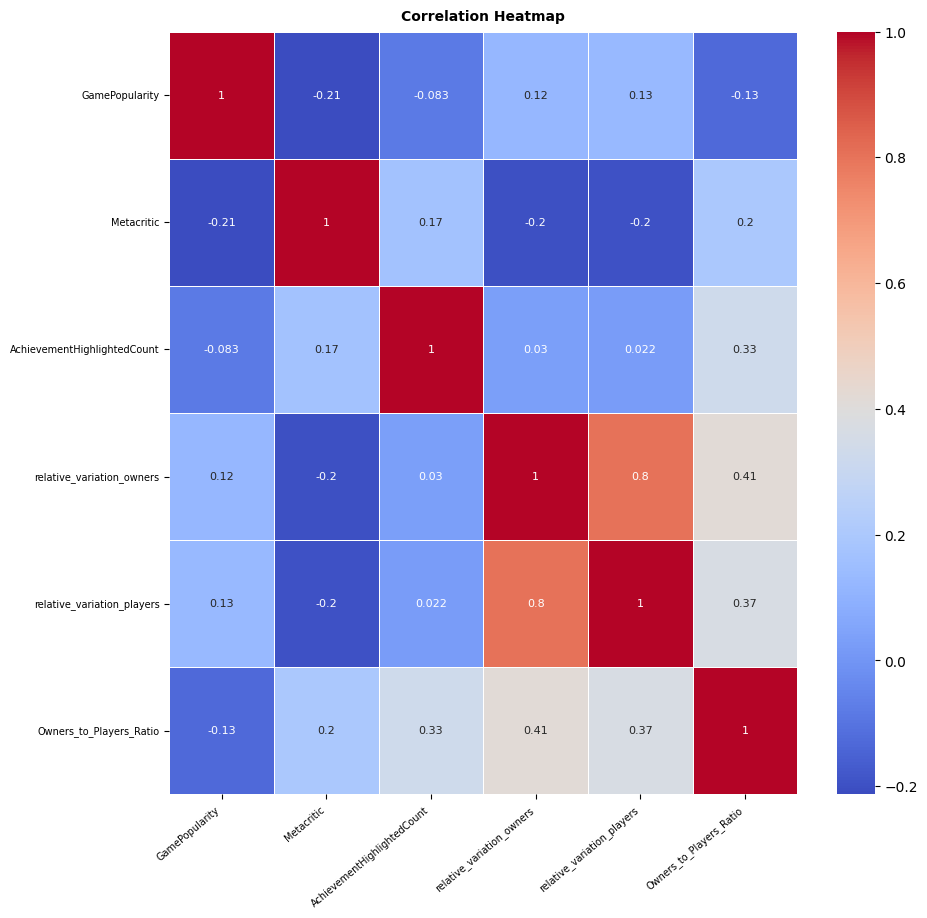


Adding Interaction Features...


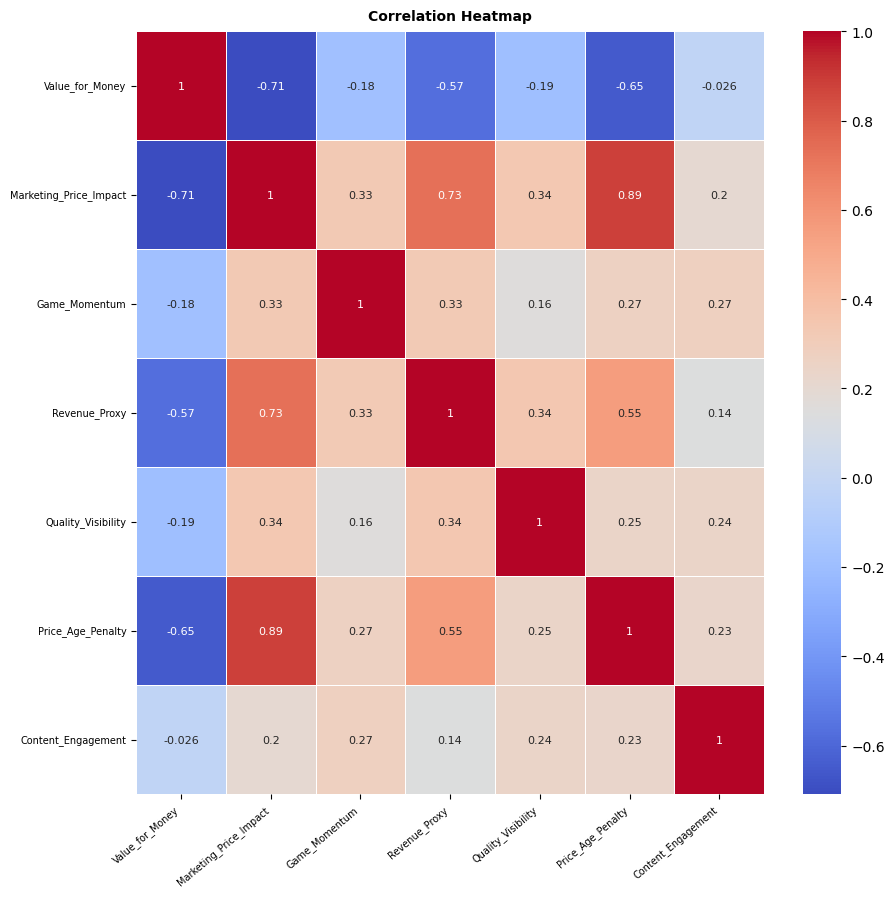


Starting Feature Filtering (Variance & Correlation)
Removed ['SubscriptionAvail', 'PlatformWindows', 'PlatformLinux', 'PlatformMac', 'CategoryCoop', 'CategoryMMO', 'CategoryIncludeSrcSDK', 'GenreIsIndie', 'GenreIsAction', 'GenreIsAdventure', 'GenreIsCasual', 'GenreIsStrategy', 'GenreIsRPG', 'GenreIsSimulation', 'GenreIsEarlyAccess', 'GenreIsFreeToPlay', 'GenreIsSports', 'GenreIsRacing', 'GenreIsMassivelyMultiplayer', 'PriceCurrency', 'HeaderImage', 'Linux_Storage_GB', 'Mac_Storage_GB', 'PC_Storage_GB'] , 
Removed 24 Zero/Low Variance Features.
Removed ['SteamSpyOwnersVariance', 'SteamSpyPlayersEstimate', 'SteamSpyPlayersVariance', 'FreeVerAvail', 'PurchaseAvail', 'PriceFinal', 'Background', 'DetailedDescrip', 'ScreenshotCount_Log', 'MovieCount_Log', 'Total_Media_Assets_log', 'Is_NonGame_Flag', 'Zero_Owners_Flag', 'PackageCount_Log', 'Achievement_Tier', 'AchievementCount_Log', 'Has_Discount', 'Engagement_Score', 'Review_Sentiment_Score', 'GameAge', 'Release_Quarter', 'Mac_OpenGL', 'Mar

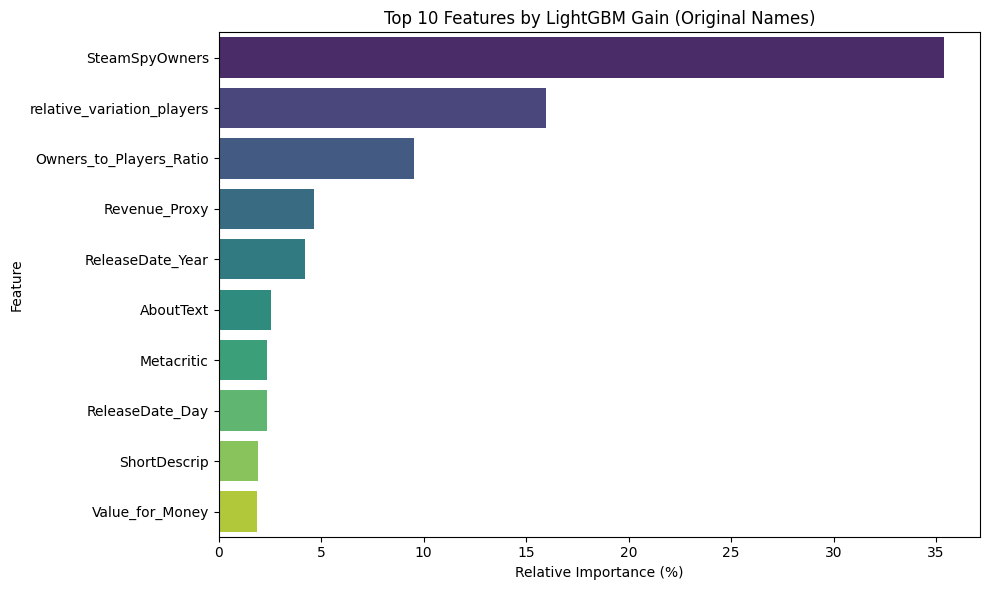

Selected Features: ['SteamSpyOwners', 'relative_variation_players', 'Owners_to_Players_Ratio', 'Revenue_Proxy', 'ReleaseDate_Year', 'AboutText', 'Metacritic', 'ReleaseDate_Day', 'ShortDescrip', 'Value_for_Money']


In [107]:
# Load data
df = pd.read_csv('/content/train_data.csv')

df_processed = run_full_pipeline(df)

X = df_processed.drop(columns=['GamePopularity']).select_dtypes(include=[np.number]).fillna(0)
y = df_processed['GamePopularity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
selected_features = lgbm_feature_selection(X_train,y_train)
print(f"Selected Features: {selected_features}")

X_train = X_train[selected_features]
X_test = X_test[selected_features]

# # Scaling
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)


In [111]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

#diff hyperprameters to choose from
dt_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [10, 15, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}


# grid to try diffrent combination of the parameter and store the best acc
grid_dt = GridSearchCV(
    DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ),
    dt_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_

y_pred_dt = best_dt.predict(X_test)

dt_acc = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_acc)

print("\nBest Parameters:")
print(grid_dt.best_params_)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

#cross validation then calc the mean of the acc to dec the overfitting
cv_scores = cross_val_score(
    best_dt,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("\nCV Accuracy Mean:", cv_scores.mean())

Decision Tree Accuracy: 0.8921654929577465

Best Parameters:
{'criterion': 'entropy', 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.76      0.76       260
           1       0.95      0.95      0.95      1882
           2       0.29      0.28      0.29       130

    accuracy                           0.89      2272
   macro avg       0.67      0.67      0.67      2272
weighted avg       0.89      0.89      0.89      2272


CV Accuracy Mean: 0.890588882773803


In [109]:
# def xgb_objective(trial):
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 300, 1200),
#         'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
#         'max_depth': trial.suggest_int('max_depth', 3, 10),
#         'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
#         'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
#         'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
#         'gamma': trial.suggest_float('gamma', 0.0, 5.0),
#         'objective': 'reg:squarederror',
#         'random_state': 42,
#         'n_jobs': -1
#     }

#     model = xgb.XGBRegressor(**params)

#     kf = KFold(n_splits=5, shuffle=True, random_state=42)

#     scores = cross_val_score(
#         model,
#         X_train_scaled,
#         y_train,
#         cv=kf,
#         scoring='r2',
#         n_jobs=-1
#     )

#     return scores.mean()


# # LightGBM to search best hyperparameters
# def lgb_objective(trial):
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 300, 1200),
#         'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
#         'max_depth': trial.suggest_int('max_depth', 3, 10),
#         'num_leaves': trial.suggest_int('num_leaves', 20, 150),
#         'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
#         'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
#         'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
#         'random_state': 42,
#         'n_jobs': -1,
#         'verbose': -1
#     }

#     model = lgb.LGBMRegressor(**params)

#     kf = KFold(n_splits=5, shuffle=True, random_state=42)

#     scores = cross_val_score(
#         model,
#         X_train_scaled,
#         y_train,
#         cv=kf,
#         scoring='r2',
#         n_jobs=-1
#     )

#     return scores.mean()


# # XGBoost


# print("=" * 50)
# print("Tuning XGBoost...")
# print("=" * 50)

# xgb_study = optuna.create_study(direction='maximize')
# xgb_study.optimize(xgb_objective, n_trials=30, show_progress_bar=True)

# best_xgb_params = xgb_study.best_params
# best_xgb_params.update({
#     'objective': 'reg:squarederror',
#     'random_state': 42,
#     'n_jobs': -1
# })

# print("Best XGBoost Params:")
# print(best_xgb_params)

# #  LightGBM

# print("=" * 50)
# print("Tuning LightGBM...")
# print("=" * 50)

# lgb_study = optuna.create_study(direction='maximize')
# lgb_study.optimize(lgb_objective, n_trials=30, show_progress_bar=True)

# best_lgb_params = lgb_study.best_params
# best_lgb_params.update({
#     'random_state': 42,
#     'n_jobs': -1,
#     'verbose': -1
# })

# print("Best LightGBM Params:")
# print(best_lgb_params)


# #  Build Models
# best_xgb_model = xgb.XGBRegressor(**best_xgb_params)
# best_lgb_model = lgb.LGBMRegressor(**best_lgb_params)

# best_xgb_model.fit(X_train_scaled, y_train)
# best_lgb_model.fit(X_train_scaled, y_train)
# xgb_test_r2 = r2_score(y_test, best_xgb_model.predict(X_test_scaled))
# lgb_test_r2 = r2_score(y_test, best_lgb_model.predict(X_test_scaled))
# print("R² of XGBoost model:", xgb_test_r2)
# print("R² of LightGBM model:", lgb_test_r2)




# # Stacking model
# stacking_model = StackingRegressor(
#     estimators=[
#         ('xgb', best_xgb_model),
#         ('lgb', best_lgb_model)
#     ],
#     final_estimator=Ridge(alpha=1.0),
#     cv=5,
#     n_jobs=-1
# )

# # Train Model
# print("=" * 50)
# print("Training Stacking Model...")
# print("=" * 50)

# stacking_model.fit(X_train_scaled,y_train)

# #  Prediction
# y_pred_log = stacking_model.predict(X_test_scaled)

# y_test_actual = np.expm1(y_test)
# y_pred_clipped = np.clip(y_pred_log, a_min=None, a_max=20)
# y_pred_actual = np.expm1(y_pred_clipped)


# # Evaluation by MSE and RMSE and apply cross validation
# r2 = r2_score(y_test, y_pred_log)
# rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
# mae = mean_absolute_error(y_test_actual, y_pred_actual)

# kf_final = KFold(n_splits=5, shuffle=True, random_state=42)

# cv_scores = cross_val_score(
#     stacking_model,
#     X,
#     y,
#     cv=kf_final,
#     scoring='r2',
#     n_jobs=-1
# )

# print("\nFinal Performance:")
# print(f"R² Score (Test): {r2:.4f}")
# print(f"R² CV Mean: {cv_scores.mean():.4f}")
# print(f"R² CV Std : {cv_scores.std():.4f}")
# print(f"RMSE      : {rmse:.2f}")
# print(f"MAE       : {mae:.2f}")
